# histogram_ln_notarget_classic_control

HL-Gauss DQN without LayerNorm (target network every 128 steps) vs. with LayerNorm and no
target network, over the same grid as `histogram_grid_classic_control`.

In [1]:
# Import the experiment config, the results loader and the analysis functions.
import itertools

import matplotlib.pyplot as plt
import numpy as np

from analysis.curves import lifetime_average, return_curve, subsample
from analysis.stats import best_by_mean, mean_ci
from main import load_results

from config import EXPERIMENT, LR_SWEEP, NUM_BINS_SWEEP, SIGMA_RATIO_SWEEP, SUPPORT_RANGES, VARIANTS

PLOTS_DIR = EXPERIMENT.results_dir.parent / "plots"

In [2]:
# Load each variant's stored runs per environment and (support, SIGMA_RATIO, NUM_BINS, LR), if stored.
ENVIRONMENTS = ["cartpole", "acrobot", "mountaincar"]

results = {}
for variant, environment, support in itertools.product(VARIANTS, ENVIRONMENTS, SUPPORT_RANGES):
    name = f"{variant}_{environment}_support{support}"
    for sigma, bins, lr in itertools.product(SIGMA_RATIO_SWEEP, NUM_BINS_SWEEP, LR_SWEEP):
        where = {
            "AGENT_HYPERS.SIGMA_RATIO": sigma,
            "AGENT_HYPERS.NUM_BINS": bins,
            "AGENT_HYPERS.LR": lr,
        }
        runs = load_results(EXPERIMENT, name, where=where)
        if runs is not None:
            results[variant, environment, support, sigma, bins, lr] = runs
print(f"loaded {len(results)} grid point(s)")

loaded 720 grid point(s)


In [3]:
# Compute each config's lifetime scores and learning curve, and each (variant, environment)'s best config.
# A config is (support, SIGMA_RATIO, NUM_BINS, LR).
scores = {}
curves = {}
for (variant, environment, *grid_point), runs in results.items():
    returns = return_curve(runs.reward, runs.done)
    scores.setdefault((variant, environment), {})[tuple(grid_point)] = lifetime_average(returns)
    timesteps, values = subsample(returns)
    curves[variant, environment, tuple(grid_point)] = (timesteps, mean_ci(values))
sensitivity = {
    key: {point: mean_ci(runs) for point, runs in by_point.items()}
    for key, by_point in scores.items()
}
best = {key: best_by_mean(by_point) for key, by_point in scores.items()}


def lr_power(lr):
    """An LR from the 4^-k grid as its exponent k, e.g. 0.000977 -> 5."""
    return round(-np.log(lr) / np.log(4))


def lr_tex(lr):
    """An LR as a mathtext power of four, for titles, legends and ticks."""
    return f"$4^{{-{lr_power(lr)}}}$"


TOP_K = 5
for (variant, environment), by_point in sensitivity.items():
    ranked = sorted(by_point.items(), key=lambda item: item[1][0], reverse=True)
    print(f"[{variant} / {environment}] top {TOP_K} of {len(ranked)} configs (support, σ/bin width, bins, LR):")
    for (support, sigma, bins, lr), (mean, low, high) in ranked[:TOP_K]:
        print(
            f"  ±{support}  σ/bin width={sigma:<4}  bins={bins:<3}  LR=4^-{lr_power(lr)}  "
            f"{mean:8.1f}  [{low:.1f}, {high:.1f}]"
        )

[dqn_hl / cartpole] top 5 of 180 configs (support, σ/bin width, bins, LR):
  ±200  σ/bin width=1.0   bins=50   LR=4^-6     405.9  [396.6, 414.3]
  ±200  σ/bin width=1.5   bins=50   LR=4^-6     396.7  [383.4, 409.4]
  ±200  σ/bin width=2.5   bins=100  LR=4^-6     396.0  [386.0, 404.8]
  ±200  σ/bin width=2.0   bins=100  LR=4^-6     393.9  [381.4, 403.9]
  ±100  σ/bin width=2.5   bins=200  LR=4^-5     390.7  [381.1, 399.6]
[dqn_hl / mountaincar] top 5 of 180 configs (support, σ/bin width, bins, LR):
  ±200  σ/bin width=1.5   bins=100  LR=4^-5    -228.2  [-244.1, -211.9]
  ±100  σ/bin width=2.5   bins=100  LR=4^-5    -229.7  [-238.3, -220.8]
  ±100  σ/bin width=1.0   bins=50   LR=4^-5    -230.4  [-240.9, -220.8]
  ±200  σ/bin width=1.0   bins=100  LR=4^-5    -233.9  [-246.6, -220.1]
  ±200  σ/bin width=2.5   bins=100  LR=4^-5    -234.1  [-263.8, -211.1]
[dqn_hl_ln_notarget / cartpole] top 5 of 180 configs (support, σ/bin width, bins, LR):
  ±100  σ/bin width=2.5   bins=200  LR=4^-6     41

In [19]:
# Style for the variant-comparison plots.
STYLE = {
    "figure.figsize": (9, 6),
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "lines.linewidth": 2.5,
    "legend.frameon": False,
}
BAND_ALPHA = 0.2
TITLES = {"cartpole": "Cartpole", "acrobot": "Acrobot", "mountaincar": "MountainCar"}
# Headroom past each task's best return, so curves and bands at the ceiling stay visible.
YLIMS = {"cartpole": (0, 525), "acrobot": (-500, 25), "mountaincar": (-1000, 25)}
LABELS = {"dqn_hl": "DQN with Histogram Loss", "dqn_hl_ln_notarget": "Agent 0 with Histogram Loss"}
COLORS = dict(zip(VARIANTS, plt.cm.tab10.colors, strict=False))
YLABEL_KW = {"rotation": 0, "ha": "right", "va": "center", "labelpad": 12}
SCORE_YLABEL = "Weighted\nlifetime\nreturn"
LR_XLABEL = "Learning rate"
SIGMA_XLABEL = "SIGMA_RATIO (σ / bin width)"
CURVE_XLABEL = "Timestep"
CURVE_YLABEL = "Return"
LEGEND = {"loc": "best"}
CURVE_TITLE = "{title}: best config per variant (95% CI)"
LR_TITLE = "{title}: LR sensitivity at each variant's best config (95% CI)"
SIGMA_TITLE = "{title}: σ sensitivity at each variant's best config (95% CI)"
CONFIG_LABEL = "{label} \n (σ/bin_width={sigma}, bins={bins}, support=±{support}, LR={lr})"
PANEL_WIDTH = 9


def draw_band(ax, x, mean, low, high, color, label, **line):
    ax.fill_between(x, low, high, color=color, alpha=BAND_ALPHA)
    ax.plot(x, mean, color=color, label=label, **line)


def config_label(variant, point):
    support, sigma, bins, lr = point
    return CONFIG_LABEL.format(
        label=LABELS[variant], sigma=sigma, bins=bins, support=support, lr=lr_tex(lr)
    )


def environment_panels():
    """One panel per environment, side by side."""
    _, height = STYLE["figure.figsize"]
    fig, axes = plt.subplots(
        1, len(ENVIRONMENTS), figsize=(PANEL_WIDTH * len(ENVIRONMENTS), height), squeeze=False
    )
    return fig, axes[0]

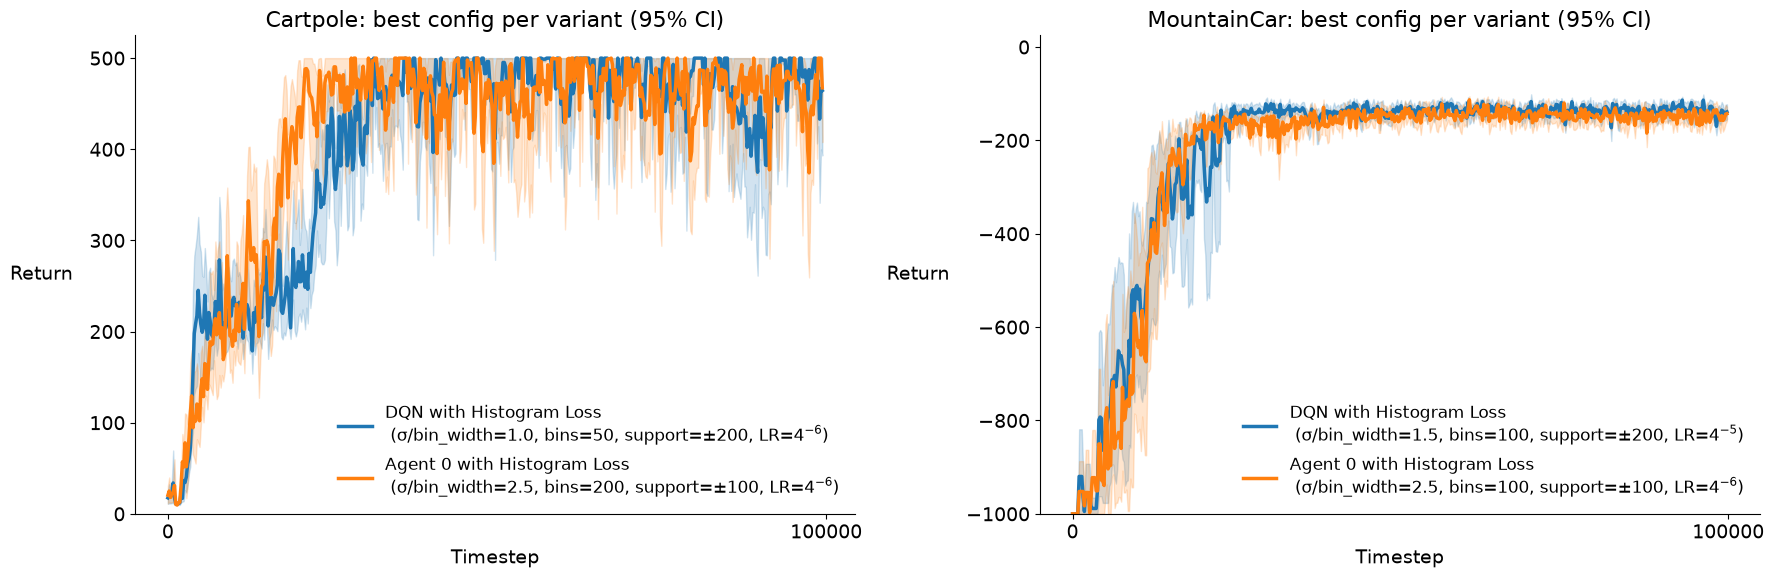

In [20]:
# Plot learning curves: each variant's best config, a panel per environment.
figures = {}
with plt.rc_context(STYLE):
    fig, axes = environment_panels()
    for ax, environment in zip(axes, ENVIRONMENTS, strict=True):
        for variant in VARIANTS:
            if (variant, environment) not in best:
                continue
            point = best[variant, environment]
            timesteps, (mean, low, high) = curves[variant, environment, point]
            draw_band(ax, timesteps, mean, low, high, COLORS[variant], config_label(variant, point))
            ax.set_xticks([0, timesteps[-1]])  # timestep axis: show only 0 and the max
        ax.set(title=CURVE_TITLE.format(title=TITLES[environment]))
        ax.set(xlabel=CURVE_XLABEL, ylim=YLIMS[environment])
        ax.set_ylabel(CURVE_YLABEL, **YLABEL_KW)
        ax.legend(**LEGEND)
    fig.tight_layout()
figures["learning_curves"] = fig
plt.show()

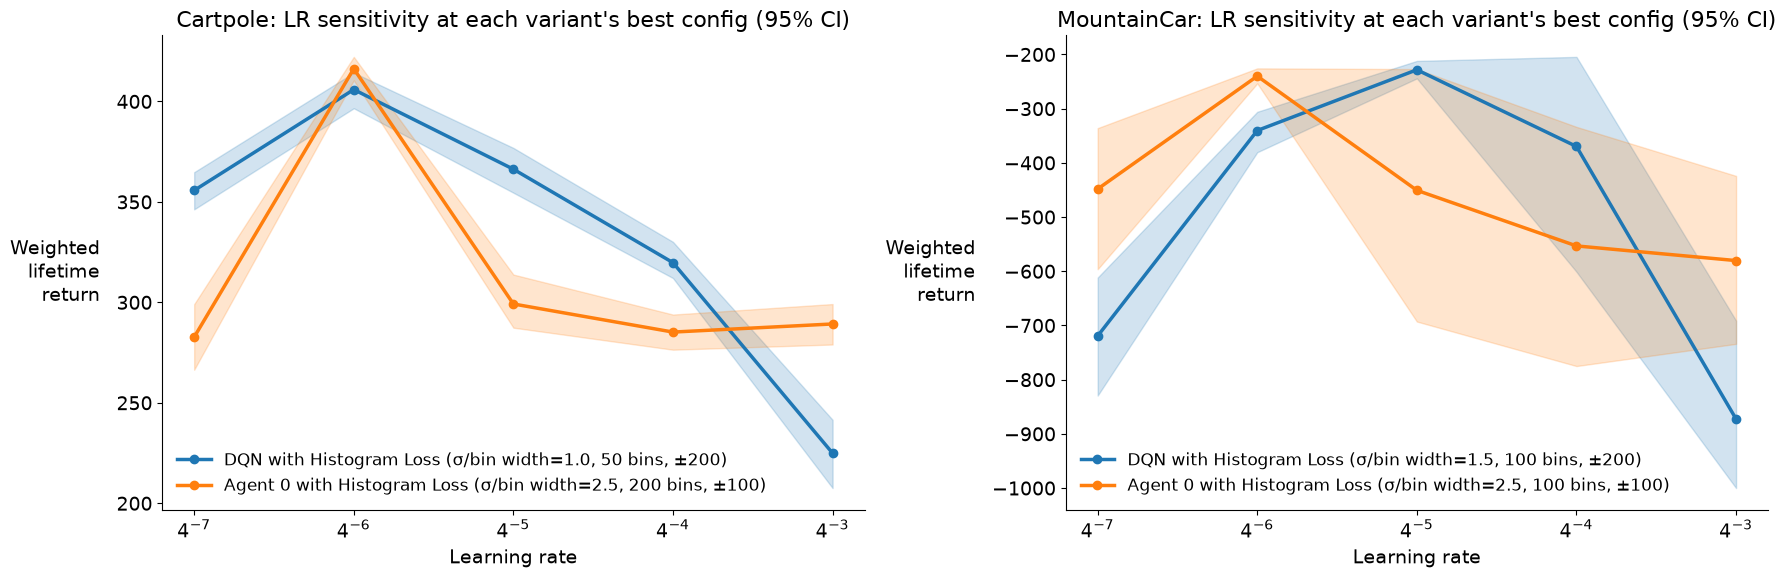

In [12]:
# Plot LR sensitivity: a line per variant at its best support, SIGMA_RATIO and NUM_BINS.
with plt.rc_context(STYLE):
    fig, axes = environment_panels()
    for ax, environment in zip(axes, ENVIRONMENTS, strict=True):
        for variant in VARIANTS:
            if (variant, environment) not in best:
                continue
            support, sigma, bins, _ = best[variant, environment]
            by_point = sensitivity[variant, environment]
            lrs = [lr for lr in LR_SWEEP if (support, sigma, bins, lr) in by_point]
            mean, low, high = np.array([by_point[support, sigma, bins, lr] for lr in lrs]).T
            label = f"{LABELS[variant]} (σ/bin width={sigma}, {bins} bins, ±{support})"
            draw_band(ax, lrs, mean, low, high, COLORS[variant], label, marker="o")
        ax.set_xscale("log")
        ax.set_xticks(LR_SWEEP, [lr_tex(lr) for lr in LR_SWEEP])
        ax.minorticks_off()
        ax.set(title=LR_TITLE.format(title=TITLES[environment]), xlabel=LR_XLABEL)
        ax.set_ylabel(SCORE_YLABEL, **YLABEL_KW)
        ax.legend(**LEGEND)
    fig.tight_layout()
figures["lr_sensitivity"] = fig
plt.show()

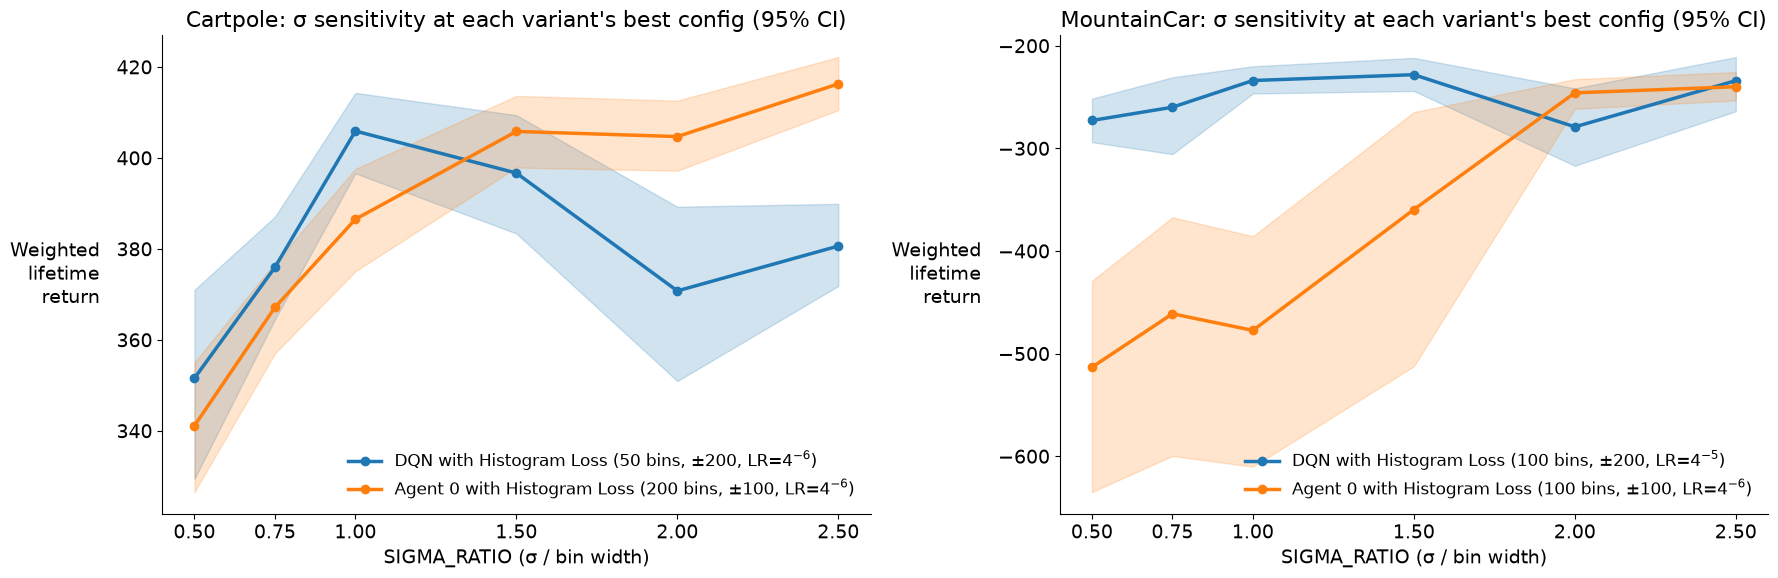

In [13]:
# Plot SIGMA_RATIO sensitivity: a line per variant at its best support, NUM_BINS and LR.
with plt.rc_context(STYLE):
    fig, axes = environment_panels()
    for ax, environment in zip(axes, ENVIRONMENTS, strict=True):
        for variant in VARIANTS:
            if (variant, environment) not in best:
                continue
            support, _, bins, lr = best[variant, environment]
            by_point = sensitivity[variant, environment]
            sigmas = [s for s in SIGMA_RATIO_SWEEP if (support, s, bins, lr) in by_point]
            mean, low, high = np.array([by_point[support, s, bins, lr] for s in sigmas]).T
            label = f"{LABELS[variant]} ({bins} bins, ±{support}, LR={lr_tex(lr)})"
            draw_band(ax, sigmas, mean, low, high, COLORS[variant], label, marker="o")
        ax.set_xticks(SIGMA_RATIO_SWEEP)
        ax.set(title=SIGMA_TITLE.format(title=TITLES[environment]), xlabel=SIGMA_XLABEL)
        ax.set_ylabel(SCORE_YLABEL, **YLABEL_KW)
        ax.legend(**LEGEND)
    fig.tight_layout()
figures["sigma_sensitivity"] = fig
plt.show()

In [14]:
# Find each variant's best config per SIGMA_RATIO, tuning support, NUM_BINS and LR separately for each σ.
best_per_sigma = {}
for (variant, environment), by_point in scores.items():
    for sigma in SIGMA_RATIO_SWEEP:
        at_sigma = {p: s for p, s in by_point.items() if p[1] == sigma}
        if at_sigma:
            best_per_sigma[variant, environment, sigma] = best_by_mean(at_sigma)

for environment, variant in itertools.product(ENVIRONMENTS, VARIANTS):
    if (variant, environment) not in best:
        continue
    print(f"[{variant} / {environment}] best config per σ/bin width (support, bins, LR):")
    for sigma in SIGMA_RATIO_SWEEP:
        if (variant, environment, sigma) not in best_per_sigma:
            continue
        point = best_per_sigma[variant, environment, sigma]
        support, _, bins, lr = point
        mean, low, high = sensitivity[variant, environment][point]
        marker = "  <- best" if point == best[variant, environment] else ""
        print(
            f"  σ/bin width={sigma:<4}  ±{support}  bins={bins:<3}  LR=4^-{lr_power(lr)}  "
            f"{mean:8.1f}  [{low:.1f}, {high:.1f}]{marker}"
        )

[dqn_hl / cartpole] best config per σ/bin width (support, bins, LR):
  σ/bin width=0.5   ±200  bins=200  LR=4^-5     386.3  [380.0, 392.7]
  σ/bin width=0.75  ±100  bins=200  LR=4^-5     381.0  [376.9, 385.1]
  σ/bin width=1.0   ±200  bins=50   LR=4^-6     405.9  [396.6, 414.3]  <- best
  σ/bin width=1.5   ±200  bins=50   LR=4^-6     396.7  [383.4, 409.4]
  σ/bin width=2.0   ±200  bins=100  LR=4^-6     393.9  [381.4, 403.9]
  σ/bin width=2.5   ±200  bins=100  LR=4^-6     396.0  [386.0, 404.8]
[dqn_hl_ln_notarget / cartpole] best config per σ/bin width (support, bins, LR):
  σ/bin width=0.5   ±100  bins=50   LR=4^-6     406.2  [402.0, 411.0]
  σ/bin width=0.75  ±100  bins=50   LR=4^-6     410.0  [401.2, 418.8]
  σ/bin width=1.0   ±100  bins=100  LR=4^-6     411.8  [403.5, 420.7]
  σ/bin width=1.5   ±100  bins=100  LR=4^-6     415.2  [405.7, 424.3]
  σ/bin width=2.0   ±100  bins=100  LR=4^-6     410.0  [403.8, 416.5]
  σ/bin width=2.5   ±100  bins=200  LR=4^-6     416.3  [410.5, 422.2]  

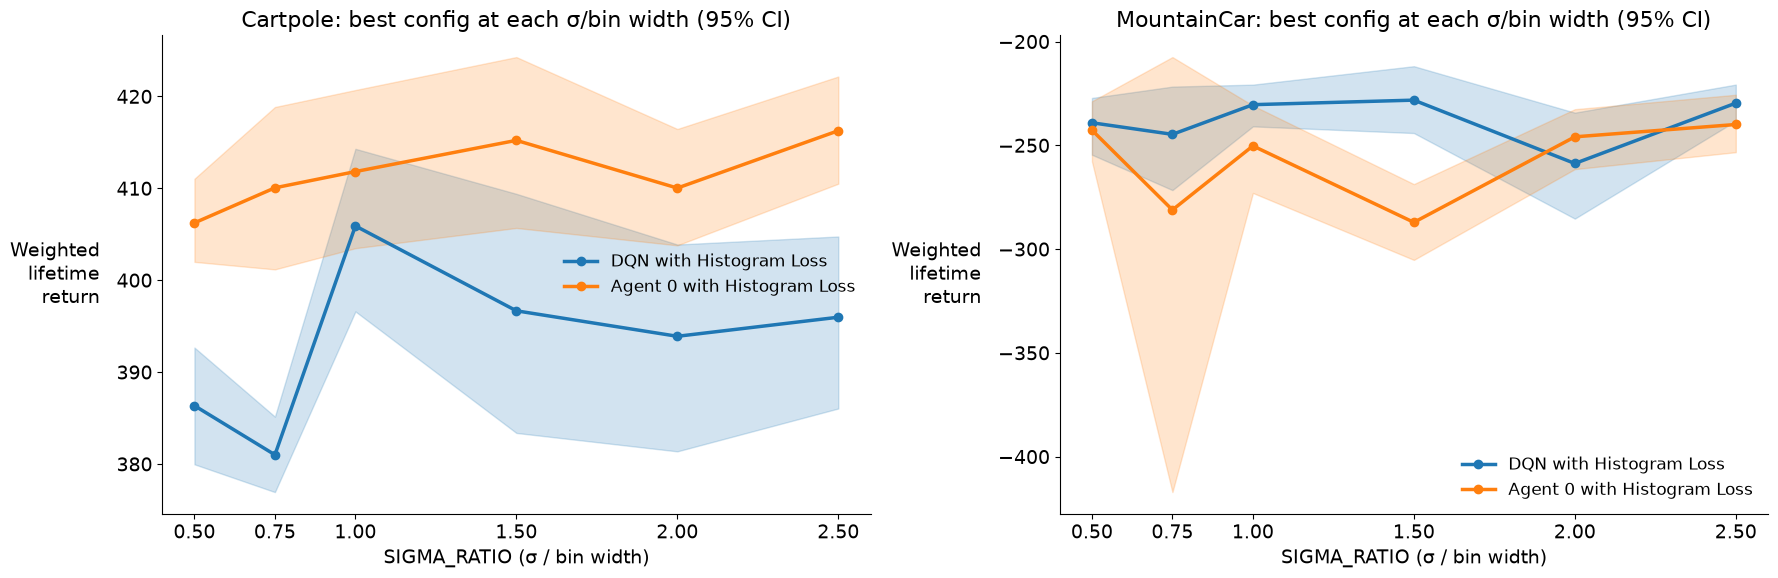

In [15]:
# Plot the best score at each SIGMA_RATIO: a line per variant, with support, NUM_BINS and LR tuned per σ.
BEST_SIGMA_TITLE = "{title}: best config at each σ/bin width (95% CI)"
with plt.rc_context(STYLE):
    fig, axes = environment_panels()
    for ax, environment in zip(axes, ENVIRONMENTS, strict=True):
        for variant in VARIANTS:
            sigmas = [s for s in SIGMA_RATIO_SWEEP if (variant, environment, s) in best_per_sigma]
            if not sigmas:
                continue
            by_point = sensitivity[variant, environment]
            intervals = [by_point[best_per_sigma[variant, environment, s]] for s in sigmas]
            mean, low, high = np.array(intervals).T
            draw_band(ax, sigmas, mean, low, high, COLORS[variant], LABELS[variant], marker="o")
        ax.set_xticks(SIGMA_RATIO_SWEEP)
        ax.set(title=BEST_SIGMA_TITLE.format(title=TITLES[environment]), xlabel=SIGMA_XLABEL)
        ax.set_ylabel(SCORE_YLABEL, **YLABEL_KW)
        ax.legend(**LEGEND)
    fig.tight_layout()
figures["best_per_sigma"] = fig
plt.show()

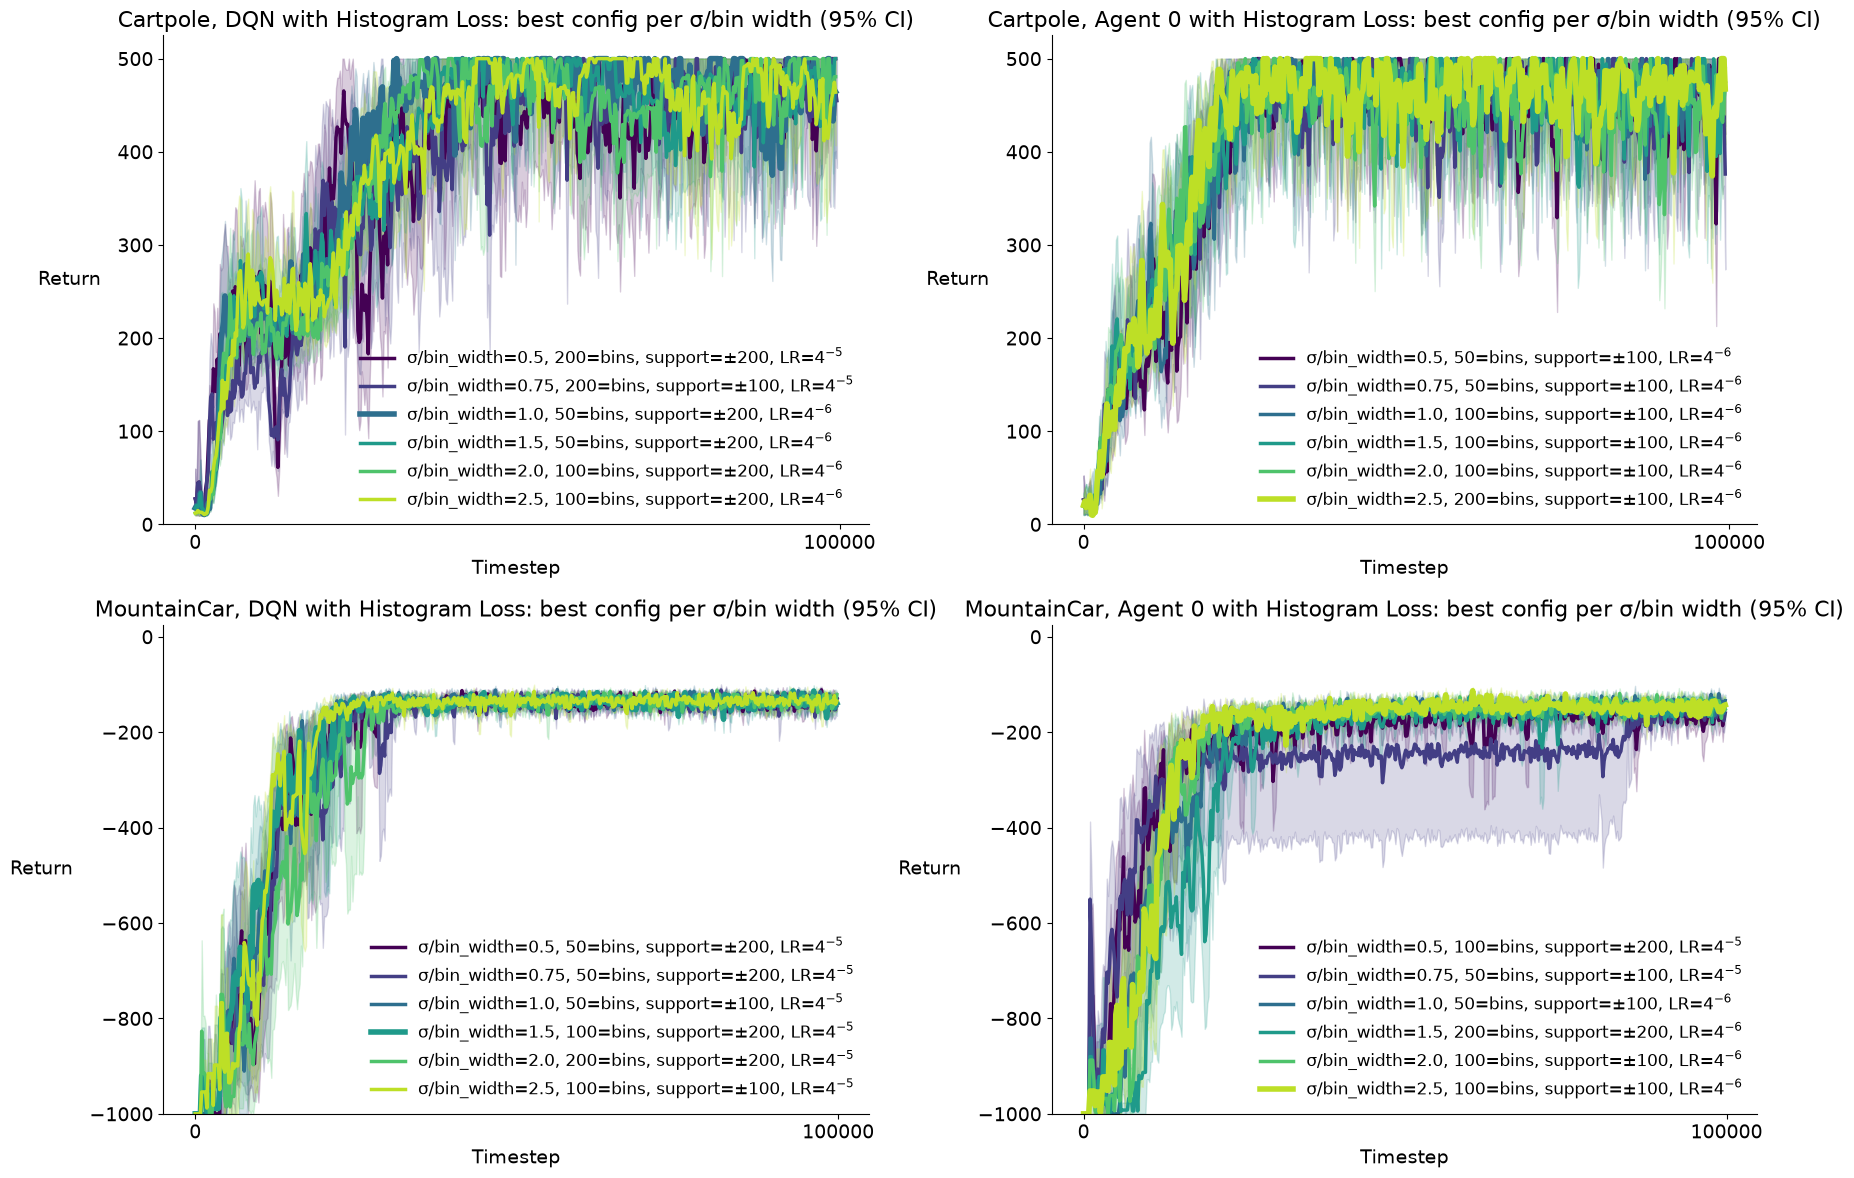

In [22]:
# Plot learning curves of the best config per SIGMA_RATIO: a row per environment, a column per variant.
SIGMA_CURVE_TITLE = "{title}, {label}: best config per σ/bin width (95% CI)"
SIGMA_CURVE_LABEL = "σ/bin_width={sigma}, bins={bins}, support=±{support}, LR={lr}"


def ordered_colors(values, cmap=plt.cm.viridis):
    """One colour per value, in order, so a swept hyper reads as a gradient."""
    return dict(zip(values, cmap(np.linspace(0, 0.9, len(values))), strict=True))


sigma_colors = ordered_colors(SIGMA_RATIO_SWEEP)
with plt.rc_context(STYLE):
    _, height = STYLE["figure.figsize"]
    fig, axes = plt.subplots(
        len(ENVIRONMENTS), len(VARIANTS),
        figsize=(PANEL_WIDTH * len(VARIANTS), height * len(ENVIRONMENTS)), squeeze=False,
    )
    for row, environment in zip(axes, ENVIRONMENTS, strict=True):
        for ax, variant in zip(row, VARIANTS, strict=True):
            for sigma in SIGMA_RATIO_SWEEP:
                if (variant, environment, sigma) not in best_per_sigma:
                    continue
                point = best_per_sigma[variant, environment, sigma]
                support, _, bins, lr = point
                timesteps, (mean, low, high) = curves[variant, environment, point]
                label = SIGMA_CURVE_LABEL.format(sigma=sigma, bins=bins, support=support, lr=lr_tex(lr))
                width = 4 if point == best[variant, environment] else STYLE["lines.linewidth"]
                draw_band(ax, timesteps, mean, low, high, sigma_colors[sigma], label, linewidth=width)
                ax.set_xticks([0, timesteps[-1]])  # timestep axis: show only 0 and the max
            title = SIGMA_CURVE_TITLE.format(title=TITLES[environment], label=LABELS[variant])
            ax.set(title=title, xlabel=CURVE_XLABEL, ylim=YLIMS[environment])
            ax.set_ylabel(CURVE_YLABEL, **YLABEL_KW)
            ax.legend(**LEGEND)
    fig.tight_layout()
figures["learning_curves_per_sigma"] = fig
plt.show()

In [ ]:
# Plot learning curves of each variant's top 5 configs per environment: a row per environment, a column per variant.
TOP_CURVES = 5
TOP_TITLE = "{title}, {label}: top {k} configs (95% CI)"
TOP_LABEL = "#{rank} σ/bin_width={sigma}, bins={bins}, support=±{support}, LR={lr}"

rank_colors = ordered_colors(range(1, TOP_CURVES + 1))
with plt.rc_context(STYLE):
    _, height = STYLE["figure.figsize"]
    fig, axes = plt.subplots(
        len(ENVIRONMENTS), len(VARIANTS),
        figsize=(PANEL_WIDTH * len(VARIANTS), height * len(ENVIRONMENTS)), squeeze=False,
    )
    for row, environment in zip(axes, ENVIRONMENTS, strict=True):
        for ax, variant in zip(row, VARIANTS, strict=True):
            by_point = sensitivity.get((variant, environment), {})
            ranked = sorted(by_point, key=lambda point: by_point[point][0], reverse=True)
            # Drawn worst-first, so the best config ends up on top.
            for rank, point in reversed(list(enumerate(ranked[:TOP_CURVES], start=1))):
                support, sigma, bins, lr = point
                timesteps, (mean, low, high) = curves[variant, environment, point]
                label = TOP_LABEL.format(
                    rank=rank, sigma=sigma, bins=bins, support=support, lr=lr_tex(lr)
                )
                width = 4 if rank == 1 else STYLE["lines.linewidth"]
                draw_band(ax, timesteps, mean, low, high, rank_colors[rank], label, linewidth=width)
                ax.set_xticks([0, timesteps[-1]])  # timestep axis: show only 0 and the max
            title = TOP_TITLE.format(title=TITLES[environment], label=LABELS[variant], k=TOP_CURVES)
            ax.set(title=title, xlabel=CURVE_XLABEL, ylim=YLIMS[environment])
            ax.set_ylabel(CURVE_YLABEL, **YLABEL_KW)
            handles, labels = ax.get_legend_handles_labels()
            ax.legend(handles[::-1], labels[::-1], **LEGEND)  # list #1 first
    fig.tight_layout()
figures["top5_learning_curves"] = fig
plt.show()

In [23]:
# Save every plotted figure as a PDF and a PNG in the plots directory.
PLOTS_DIR.mkdir(exist_ok=True)
for name, fig in figures.items():
    fig.savefig(PLOTS_DIR / f"{name}.pdf", bbox_inches="tight")
    fig.savefig(PLOTS_DIR / f"{name}.png", bbox_inches="tight", dpi=200)
print(f"saved {len(figures)} plot(s) to {PLOTS_DIR}")

saved 2 plot(s) to /Users/sethlinc/CodingProjects/rl-jax/experiments/histogram_ln_notarget_classic_control/plots
